In [ ]:
import pandas as pd

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("silver_prices_data.csv")

In [ ]:
df.head()

,Date,Price
0,1/24/2011,27.318001
1,1/25/2011,26.811001
2,1/26/2011,27.132000
3,1/27/2011,27.045000
4,1/28/2011,27.934000


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df.head()

,Price
Date,
2011-01-24,27.318001
2011-01-25,26.811001
2011-01-26,27.132000
2011-01-27,27.045000
2011-01-28,27.934000


In [ ]:
resampled_data = df['Price'].resample('Y').sum().to_frame()
resampled_data.head()

/tmp/ipykernel_7695/2914988013.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled_data = df['Price'].resample('Y').sum().to_frame()


,Price
Date,
2011-12-31,8477.085007
2012-12-31,7785.259029
2013-12-31,5984.229990
2014-12-31,4795.653989
2015-12-31,3945.710995


In [ ]:
resampled_data.index = resampled_data.index.year


In [ ]:
resampled_data.reset_index(inplace=True)

In [ ]:
resampled_data.head()

,level_0,index,Date,Price,Linear Trend,Polynomial Trend
0,0,0,2011,8477.085007,5946.829723,7290.828625
1,1,1,2012,7785.259029,5891.733444,6698.132785
2,2,2,2013,5984.229990,5836.637165,6182.236882
3,3,3,2014,4795.653989,5781.540885,5743.140917
4,4,4,2015,3945.710995,5726.444606,5380.844889


In [ ]:

date = resampled_data['Date'].tolist()

In [ ]:
resampled_data['Date'] = date

In [ ]:
price = resampled_data['Price'].tolist()

In [ ]:
X = [i - date[len(date) // 2] for i in date]

In [ ]:
x2 = [i ** 2 for i in X]

In [ ]:
xy = [i * j for i, j in zip(X, price)]

In [ ]:
n = len(date)

In [ ]:
b = (n * sum(xy) - sum(price) * sum(X)) / (n * sum(x2) - (sum(X) ** 2))


In [ ]:
a = (sum(price) - b * sum(X)) / n


In [ ]:
linear_trend = [a + b * X[i] for i in range(n)]


In [ ]:
x3 = [i ** 3 for i in X]


In [ ]:
x4 = [i ** 4 for i in X]
x2y = [i * j for i, j in zip(x2, price)]


In [ ]:
coeff = [[len(X), sum(X), sum(x2)],
[sum(X), sum(x2), sum(x3)],
[sum(x2), sum(x3), sum(x4)]]

In [ ]:
Y = [sum(price), sum(xy), sum(x2y)]

In [ ]:
A = np.array(coeff)


In [ ]:
B = np.array(Y)


In [ ]:
solution = np.linalg.solve(A, B)
a_poly, b_poly, c_poly = solution
poly_trend = [a_poly + b_poly * X[i] + c_poly * (X[i] ** 2) for i in range(n)]

In [ ]:
print(f"Linear Trend: y={a:.2f} + {b:.2f}x")
print(f"\nPolynomial Trend: y={a_poly:.2f} + {b_poly:.2f}x + {c_poly:.2f}x²")

Linear Trend: y=5506.06 + -55.10x

Polynomial Trend: y=4699.66 + -16.70x + 38.40x²


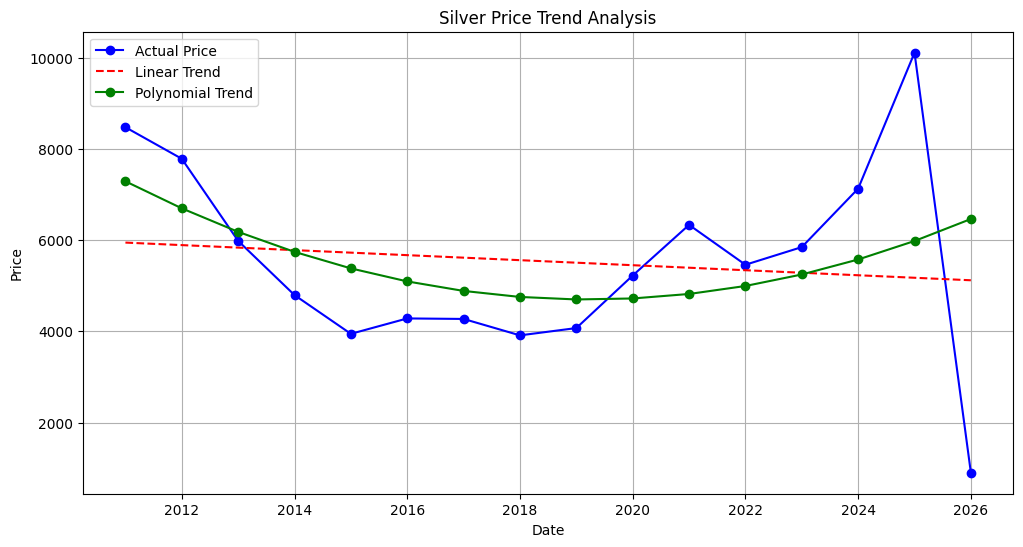

In [ ]:
resampled_data['Linear Trend'] = linear_trend
resampled_data['Polynomial Trend'] = poly_trend
plt.figure(figsize=(12, 6))
resampled_data['Price'].plot(kind='line',color='blue',marker='o', label='Actual Price')
resampled_data['Linear Trend'].plot(kind='line',color='red',linestyle='--', label='Linear Trend')
resampled_data['Polynomial Trend'].plot(kind='line',color='green',marker='o', label='Polynomial Trend')
plt.title('Silver Price Trend Analysis')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()